## 1. What this notebook computes

This notebook turns the first half of many-body quantum mechanics into numbers that
can be checked. It

- evaluates the Slater determinant of two fermions on three points (every value,
  the normalisation and the density) and draws a two-fermion determinant in a box;
- builds the creation and annihilation operators of four orbitals as $16 \times 16$
  matrices and checks the anticommutation relations;
- checks Wick's theorem (every expectation value of a determinant is made of its
  density matrix) for a determinant and for a thermal ensemble, and the formula for
  the normal-ordered square of a one-body vertex that the Revision Kohn-Sham theory
  uses;
- checks the energy formula of a determinant (direct minus exchange terms);
- solves the model of two electrons on two sites exactly, and in restricted and
  unrestricted Hartree-Fock, and compares energies, correlation energy and double
  occupancy for all strengths of the repulsion;
- shows the Hohenberg-Kohn theorem at work on two sites (the density determines the
  site-energy difference) and finds the exact Kohn-Sham potential by inverting the
  density;
- draws eight teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 13c (Slater determinants, second quantization and the two-site model) is the
file `Revision/textbook/notebooks/13c_two_site_model.ipynb` of the repository
Dirac_claude. It evaluates Slater determinants of two fermions (on three points and in a
box), builds the creation and annihilation operators of four orbitals as 16 x 16 matrices
and checks their anticommutation relations, Wick's theorem for a determinant and for a
thermal ensemble, the normal-ordered square of a one-body vertex and the energy formula
of a determinant; it then solves the two-site model with two electrons exactly and in
restricted and unrestricted Hartree-Fock (energies, correlation energy, double occupancy,
the Hartree-Fock energy landscape), and shows the Hohenberg-Kohn map from the site-energy
difference to the density and its exact Kohn-Sham inversion, with eight teaching plots.
It needs a computer with Windows 11, macOS or Linux, an internet connection for the
installation, the program Git, and Python 3.12 or newer (the notebooks were built with
Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0,
mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2,
ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy and matplotlib;
the other packages run Jupyter, the program that shows and runs notebooks. It does not
need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 13c_two_site_model.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 13c_two_site_model.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
13c_two_site_model.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/13c.captions.json`
- `Revision/textbook/figures/13c_1_slater_determinants.png`
- `Revision/textbook/figures/13c_2_operator_matrices.png`
- `Revision/textbook/figures/13c_3_density_matrices.png`
- `Revision/textbook/figures/13c_4_two_site_energies.png`
- `Revision/textbook/figures/13c_5_double_occupancy.png`
- `Revision/textbook/figures/13c_6_hf_landscape.png`
- `Revision/textbook/figures/13c_7_density_map.png`
- `Revision/textbook/figures/13c_8_ks_inversion.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 13c_8_ks_inversion.png exists
    ALL 33 CHECKS PASSED (notebook 13c)

and the notebook must show 8 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/13c_two_site_model.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 13c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 13c (Slater determinants, second quantization and the two-site model) is the
# file Revision/textbook/notebooks/13c_two_site_model.ipynb of the repository
# Dirac_claude. It evaluates Slater determinants of two fermions (on three points and in
# a box), builds the creation and annihilation operators of four orbitals as 16 x 16
# matrices and checks their anticommutation relations, Wick's theorem for a determinant
# and for a thermal ensemble, the normal-ordered square of a one-body vertex and the
# energy formula of a determinant; it then solves the two-site model with two electrons
# exactly and in restricted and unrestricted Hartree-Fock (energies, correlation energy,
# double occupancy, the Hartree-Fock energy landscape), and shows the Hohenberg-Kohn map
# from the site-energy difference to the density and its exact Kohn-Sham inversion, with
# eight teaching plots. It needs a computer with Windows 11, macOS or Linux, an internet
# connection for the installation, the program Git, and Python 3.12 or newer (the
# notebooks were built with Python 3.14.5) with these packages at exactly these versions:
# numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
# 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
# imports numpy and matplotlib; the other packages run Jupyter, the program that shows
# and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 13c_two_site_model.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 13c_two_site_model.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 13c_two_site_model.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/13c.captions.json
# - Revision/textbook/figures/13c_1_slater_determinants.png
# - Revision/textbook/figures/13c_2_operator_matrices.png
# - Revision/textbook/figures/13c_3_density_matrices.png
# - Revision/textbook/figures/13c_4_two_site_energies.png
# - Revision/textbook/figures/13c_5_double_occupancy.png
# - Revision/textbook/figures/13c_6_hf_landscape.png
# - Revision/textbook/figures/13c_7_density_map.png
# - Revision/textbook/figures/13c_8_ks_inversion.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 13c_8_ks_inversion.png exists
#     ALL 33 CHECKS PASSED (notebook 13c)
#
# and the notebook must show 8 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/13c_two_site_model.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "13c"  # this notebook: chapter 13, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 13c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Orbital**: a one-particle state; here either a function on a few points or one
  of a finite list of basis states.
- **Slater determinant**: the antisymmetric state of $N$ fermions built from $N$
  orthonormal orbitals, $\Phi = \det[\phi_a(x_i)]/\sqrt{N!}$.
- **Antisymmetric**: changing sign when two particles are exchanged.
- **Occupation-number state** $|n_0 n_1 n_2 n_3\rangle$: the determinant that uses
  the orbitals $p$ with $n_p = 1$; there are $2^4 = 16$ of them for four orbitals.
- **Creation operator** $a_p^\dagger$, **annihilation operator** $a_p$: add or
  remove a fermion in orbital $p$, with the sign $(-1)^{\nu_p}$, where $\nu_p$ is the
  number of occupied orbitals before $p$; on the 16 occupation-number states they
  are $16 \times 16$ matrices.
- **Anticommutator** $\{A, B\} = AB + BA$.
- **Density matrix** $\rho_{qp} = \langle a_p^\dagger a_q\rangle$; for a determinant
  its eigenvalues are 0 and 1, for a thermal ensemble the occupation probabilities.
- **Wick's theorem**: $\langle a_p^\dagger a_q^\dagger a_s a_r\rangle =
  \rho_{rp}\rho_{sq} - \rho_{sp}\rho_{rq}$ for determinants and thermal ensembles of
  non-interacting fermions.
- **Two-site model**: two places L and R, one orbital each, two labels (up, down);
  hopping $t$ between the sites, repulsion $U$ when both electrons sit on the same
  site.
- **Hartree-Fock (HF)**: the best single determinant; **restricted** (both labels in
  the same orbital) or **unrestricted** (each label its own orbital).
- **Correlation energy**: the exact ground-state energy minus the Hartree-Fock
  energy (never positive).
- **Double occupancy**: the probability that both electrons sit on the same site.
- **Hohenberg-Kohn theorem**: the ground-state density determines the external
  potential (up to a constant); **Kohn-Sham inversion**: finding the potential of
  NON-interacting electrons that gives the same density.

## 4. The physical and mathematical situation

**Determinants.** For fermion 1 at the position $r_1$ and fermion 2 at $r_2$, in
the orthonormal orbitals $\phi_a$, $\phi_b$,
$\Phi(r_1, r_2) = [\phi_a(r_1)\phi_b(r_2) - \phi_b(r_1)\phi_a(r_2)]/\sqrt2$. It is
antisymmetric, vanishes when $r_1 = r_2$, is normalised, and its density is
$|\phi_a|^2 + |\phi_b|^2$. (The letters $r_1$, $r_2$ name the positions of the two
particles; they are not coordinates of spacetime.)

**Operators.** With four orbitals the occupation-number states are the 16 numbers
$0, \dots, 15$ written in binary: bit $p$ of the number is $n_p$. The matrix of
$a_p$ maps a state with $n_p = 1$ to the state with $n_p = 0$, times
$(-1)^{\nu_p}$; $a_p^\dagger$ is its transpose. The anticommutation relations
$\{a_p, a_q^\dagger\} = \delta_{pq}$, $\{a_p, a_q\} = 0$ follow.

**The two-site model.** The four orbitals are L up, R up, L down, R down (numbers 0,
1, 2, 3). With site energies $-\Delta/2$ (L) and $+\Delta/2$ (R),

$$\hat H = -t\sum_{\sigma}(a_{L\sigma}^\dagger a_{R\sigma} + a_{R\sigma}^\dagger
a_{L\sigma}) + U(\hat n_{L\uparrow}\hat n_{L\downarrow} + \hat n_{R\uparrow}\hat
n_{R\downarrow}) - \tfrac{\Delta}{2}\hat n_L + \tfrac{\Delta}{2}\hat n_R .$$

For $\Delta = 0$ the exact ground-state energy of two electrons with opposite labels
is $E_0 = \tfrac12(U - \sqrt{U^2 + 16t^2})$.

**Hartree-Fock.** A determinant with the up orbital $(\cos\alpha, \sin\alpha)$ and
the down orbital $(\cos\beta, \sin\beta)$ on (L, R) has the energy
$E(\alpha, \beta) = -t(\sin 2\alpha + \sin 2\beta) + \tfrac{U}{2}(1 + \cos 2\alpha
\cos 2\beta)$ (hopping energy of each orbital, plus $U$ times the double
occupancy). Restricted HF ($\alpha = \beta = \pi/4$) gives $-2t + U/2$; the
minimum over all $\alpha, \beta$ is $-2t + U/2$ for $U \le 2t$ and $-2t^2/U$ for
$U > 2t$ (unrestricted).

**Units.** All energies are in units of the hopping $t$ ($t = 1$).

**Status.** Exact finite-dimensional mathematics (PROVED: every statement follows
from the definitions; this notebook checks each one to rounding). No Revision number
is reproduced; the Wick identity for the normal-ordered square is the one of the
Revision check hf_wick_contraction.

## 5. A Slater determinant on three points

Space is three points $r = 0, 1, 2$; the orbitals are $\phi_0 = (1, 0, 0)$ and
$\phi_1 = (0, 1, 1)/\sqrt2$. The next cell builds the $3 \times 3$ table of
$\Phi(r_1, r_2)$ (row $r_1$, column $r_2$), checks its values, its antisymmetry, its
normalisation $\sum |\Phi|^2 = 1$ and its density
$n(r) = 2\sum_{r_2}|\Phi(r, r_2)|^2 = (1, \tfrac12, \tfrac12)$.

In [2]:
import itertools  # loops over all combinations of indices

import numpy as np  # arrays, matrices and linear algebra

phi0 = np.array([1.0, 0.0, 0.0])
phi1 = np.array([0.0, 1.0, 1.0]) / np.sqrt(2.0)
# Phi[r1, r2] = (phi0(r1) phi1(r2) - phi1(r1) phi0(r2)) / sqrt(2)
Phi = (np.outer(phi0, phi1) - np.outer(phi1, phi0)) / np.sqrt(2.0)
for r1 in range(3):
    say("Phi(%d, r2) for r2 = 0, 1, 2: %s" % (r1, np.array2string(
        Phi[r1], precision=6, floatmode="fixed", suppress_small=True)))
density_3 = 2.0 * np.sum(Phi ** 2, axis=1)  # n(r) = N sum_r2 |Phi(r, r2)|^2
check(abs(Phi[0, 1] - 0.5) < 1e-15 and abs(Phi[1, 2]) < 1e-15,
      "Phi(0,1) = 1/2 and Phi(1,2) = 0")
check(np.allclose(Phi, -Phi.T, atol=1e-15) and np.allclose(np.diag(Phi), 0.0),
      "Phi is antisymmetric and zero on the diagonal (Pauli)")
check(abs(np.sum(Phi ** 2) - 1.0) < 1e-15
      and np.allclose(density_3, [1.0, 0.5, 0.5], atol=1e-15)
      and np.allclose(density_3, phi0 ** 2 + phi1 ** 2, atol=1e-15),
      "Phi is normalised and its density is (1, 1/2, 1/2) = phi0^2 + phi1^2")

Phi(0, r2) for r2 = 0, 1, 2: [0.000000 0.500000 0.500000]
Phi(1, r2) for r2 = 0, 1, 2: [-0.500000  0.000000  0.000000]
Phi(2, r2) for r2 = 0, 1, 2: [-0.500000  0.000000  0.000000]
PASS Phi(0,1) = 1/2 and Phi(1,2) = 0
PASS Phi is antisymmetric and zero on the diagonal (Pauli)
PASS Phi is normalised and its density is (1, 1/2, 1/2) = phi0^2 + phi1^2


The next cell draws this table and, next to it, the determinant of the two lowest
orbitals $\sqrt2\sin(\pi x)$ and $\sqrt2\sin(2\pi x)$ of a particle in the box
$0 < x < 1$ as a heat map over the positions $(r_1, r_2)$ of the two fermions.

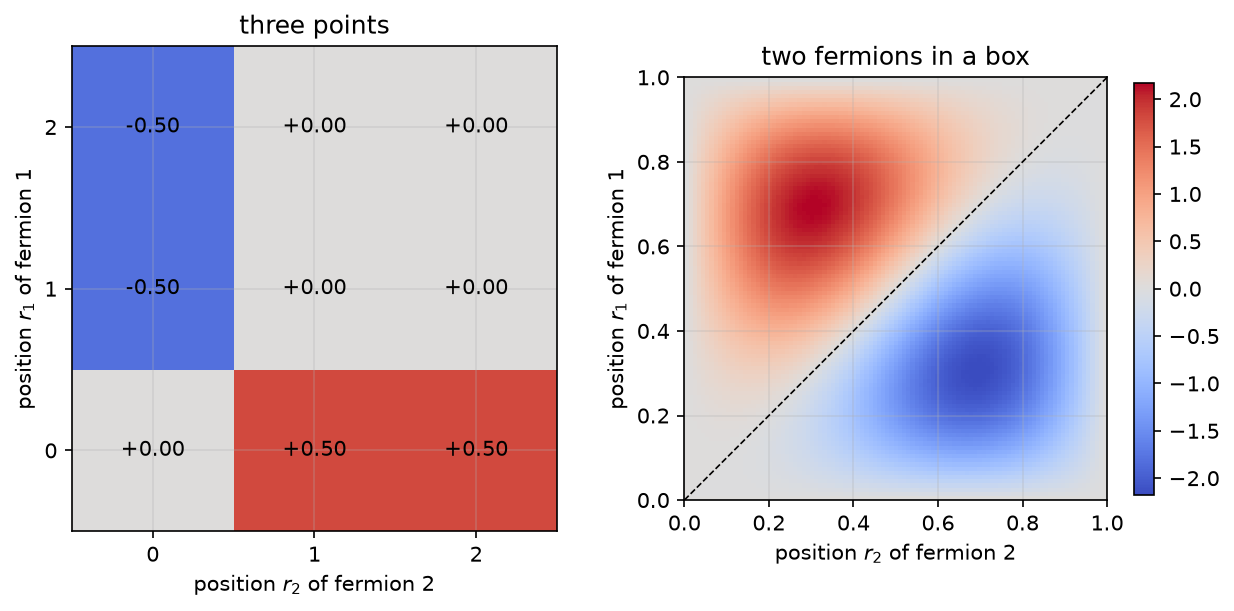

Figure 13c.1 saved as Revision/textbook/figures/13c_1_slater_determinants.png
PASS the box determinant is antisymmetric


In [3]:
x_box = np.linspace(0.0, 1.0, 101)
chi1 = np.sqrt(2.0) * np.sin(np.pi * x_box)
chi2 = np.sqrt(2.0) * np.sin(2.0 * np.pi * x_box)
Phi_box = (np.outer(chi1, chi2) - np.outer(chi2, chi1)) / np.sqrt(2.0)
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.2))
image = left.imshow(Phi, origin="lower", cmap="coolwarm", vmin=-0.6, vmax=0.6)
for r1, r2 in itertools.product(range(3), repeat=2):  # write every value in
    left.text(r2, r1, f"{Phi[r1, r2]:+.2f}", ha="center", va="center")
left.set_xticks([0, 1, 2])
left.set_yticks([0, 1, 2])
left.set_xlabel("position $r_2$ of fermion 2")
left.set_ylabel("position $r_1$ of fermion 1")
left.set_title("three points")
image = right.imshow(Phi_box, origin="lower", extent=(0, 1, 0, 1),
                     cmap="coolwarm")
right.plot([0, 1], [0, 1], "k--", lw=0.8)
right.set_xlabel("position $r_2$ of fermion 2")
right.set_ylabel("position $r_1$ of fermion 1")
right.set_title("two fermions in a box")
fig.colorbar(image, ax=right, shrink=0.85)
save_figure(fig, "slater_determinants",
            "Two Slater determinants of two fermions as heat maps (red positive, "
            "blue negative): left, $\\Phi(r_1, r_2)$ on three points for the "
            "orbitals $(1,0,0)$ and $(0,1,1)/\\sqrt2$ with its values written in; "
            "right, the determinant of the two lowest orbitals of a box "
            "$0 < x < 1$, against the positions $r_1$ (vertical) and $r_2$ "
            "(horizontal) of the two fermions. Both change sign when $r_1$ and "
            "$r_2$ are exchanged (mirror in the dashed diagonal) and vanish on the "
            "diagonal: two identical fermions are never at the same place.")
check(np.allclose(Phi_box, -Phi_box.T, atol=1e-14), "the box determinant is "
      "antisymmetric")

## 6. Creation and annihilation operators as matrices

The next cell builds the matrices $a_0, \dots, a_3$ on the 16 occupation-number
states. The state number $s$ has $n_p = $ bit $p$ of $s$ (in Python `(s >> p) & 1`);
removing the fermion of orbital $p$ gives the state number `s ^ (1 << p)` (bit $p$
switched off), with the sign $(-1)^{\nu_p}$, $\nu_p = n_0 + \dots + n_{p-1}$. Then
it checks all anticommutation relations.

In [4]:
M = 4  # orbitals
DIM = 2 ** M  # occupation-number states


def bit(state, p):
    """The occupation n_p (0 or 1) of orbital p in the state number state."""
    return (state >> p) & 1


a = []  # a[p] is the 16 x 16 matrix of the annihilation operator a_p
for p in range(M):
    matrix = np.zeros((DIM, DIM))
    for state in range(DIM):
        if bit(state, p) == 1:
            nu = sum(bit(state, q) for q in range(p))  # occupied before p
            matrix[state ^ (1 << p), state] = (-1) ** nu
    a.append(matrix)
a_dag = [matrix.T for matrix in a]  # creation operators: the transposes
identity = np.eye(DIM)
worst = 0.0
for p, q in itertools.product(range(M), repeat=2):
    worst = max(worst,
                np.abs(a[p] @ a_dag[q] + a_dag[q] @ a[p] - (p == q) * identity).max(),
                np.abs(a[p] @ a[q] + a[q] @ a[p]).max(),
                np.abs(a_dag[p] @ a_dag[q] + a_dag[q] @ a_dag[p]).max())
check(worst == 0.0, "{a_p, a_q^dag} = delta_pq and {a_p, a_q} = 0 exactly")
number = sum(a_dag[p] @ a[p] for p in range(M))  # the particle-number operator
check(np.array_equal(np.diag(number), [bin(s).count("1") for s in range(DIM)]),
      "the number operator counts the occupied orbitals of every state")

PASS {a_p, a_q^dag} = delta_pq and {a_p, a_q} = 0 exactly
PASS the number operator counts the occupied orbitals of every state


The next cell draws two of these matrices. Every column of $a_1^\dagger$ has at most
one nonzero entry ($\pm 1$): the operator moves a state to exactly one other state,
and the sign records how many occupied orbitals it had to pass.

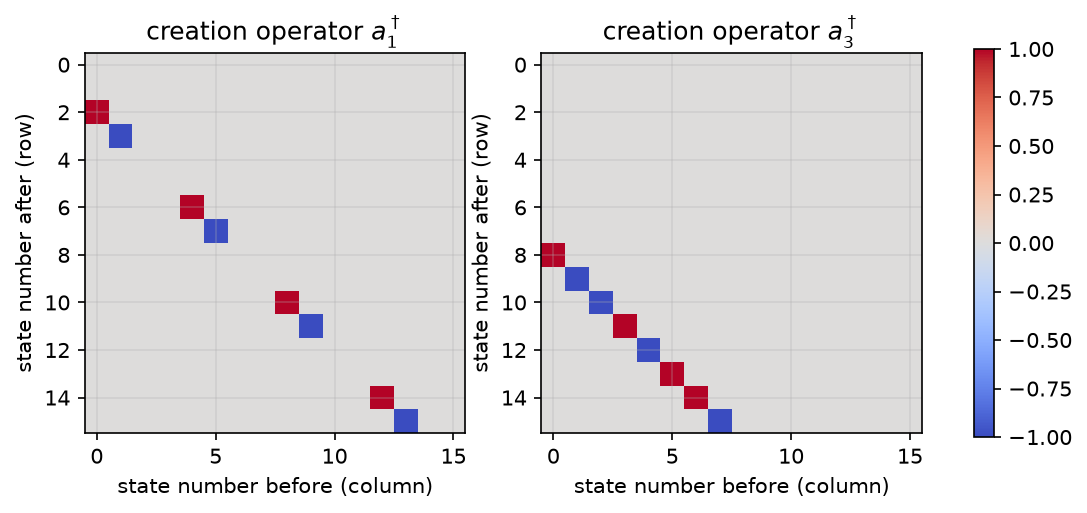

Figure 13c.2 saved as Revision/textbook/figures/13c_2_operator_matrices.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.2))
for ax, p in zip(axes, (1, 3)):
    image = ax.imshow(a_dag[p], cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(f"creation operator $a_{p}^\\dagger$")
    ax.set_xlabel("state number before (column)")
    ax.set_ylabel("state number after (row)")
fig.colorbar(image, ax=axes, shrink=0.8)
save_figure(fig, "operator_matrices",
            "The creation operators $a_1^\\dagger$ (left) and $a_3^\\dagger$ "
            "(right) of four orbitals as $16 \\times 16$ matrices on the "
            "occupation-number states $0, \\dots, 15$ (bit $p$ of the state number "
            "is $n_p$); red $+1$, blue $-1$, grey 0. A column has one entry when "
            "orbital $p$ is empty in that state and none when it is occupied "
            "(Pauli); the sign is $(-1)^{\\nu_p}$, the parity of the number of "
            "occupied orbitals before $p$.")

## 7. Wick's theorem for a determinant and for a thermal ensemble

The next cell mixes the four orbitals with a random unitary $4 \times 4$ matrix $U$
(from the QR factorisation of a random complex matrix with a fixed seed), builds the
new creation operators $a_p'^\dagger = \sum_k U_{kp}a_k^\dagger$, and the determinant
$|\Phi\rangle = a_0'^\dagger a_1'^\dagger|0\rangle$ that occupies the new orbitals 0
and 1. Its density matrix is $\rho = \sum_{a = 0, 1} U_{:,a}U_{:,a}^\dagger$. It
then checks $\langle a_p^\dagger a_q\rangle = \rho_{qp}$ and all 256 four-operator
expectation values against Wick's formula.

In [6]:
rng = np.random.default_rng(12345)  # fixed seed: the same numbers every run
U_mix = np.linalg.qr(rng.normal(size=(M, M)) + 1j * rng.normal(size=(M, M)))[0]
a_dag_new = [sum(U_mix[k, p] * a_dag[k] for k in range(M)) for p in range(M)]
vacuum = np.zeros(DIM)
vacuum[0] = 1.0  # state number 0: no fermion at all
Phi_state = a_dag_new[0] @ a_dag_new[1] @ vacuum
rho_det = sum(np.outer(U_mix[:, k], U_mix[:, k].conj()) for k in (0, 1))


def wick_errors(expect, rho):
    """Largest errors of <a+_p a_q> = rho_qp and of the four-operator formula."""
    two = max(abs(expect(a_dag[p] @ a[q]) - rho[q, p])
              for p, q in itertools.product(range(M), repeat=2))
    four = max(abs(expect(a_dag[p] @ a_dag[q] @ a[s] @ a[r])
                   - (rho[r, p] * rho[s, q] - rho[s, p] * rho[r, q]))
               for p, q, r, s in itertools.product(range(M), repeat=4))
    return two, four


def in_determinant(operator):
    """<Phi| operator |Phi> for the determinant Phi_state."""
    return np.vdot(Phi_state, operator @ Phi_state)


check(abs(np.vdot(Phi_state, Phi_state) - 1.0) < 1e-14, "the determinant is "
      "normalised")
two, four = wick_errors(in_determinant, rho_det)  # the largest errors (rounding)
check(two < 1e-14 and four < 1e-14,
      "Wick's theorem holds for the determinant (all 16 + 256 values, to 1e-14)")
check(np.allclose(rho_det @ rho_det, rho_det, atol=1e-14)
      and abs(np.trace(rho_det).real - 2.0) < 1e-14,
      "the density matrix of a determinant obeys rho^2 = rho, Tr rho = 2")

PASS the determinant is normalised
PASS Wick's theorem holds for the determinant (all 16 + 256 values, to 1e-14)
PASS the density matrix of a determinant obeys rho^2 = rho, Tr rho = 2


For a **thermal ensemble** of non-interacting fermions with the orbital energies
$\epsilon_p$ in the mixed orbitals, the density operator on the 16 states is
$e^{-(\hat H_0 - \mu\hat N)/T}/Z$ with $\hat H_0 = \sum_p \epsilon_p
a_p'^\dagger a_p'$. The next cell builds it (the exponential of a Hermitian matrix
through its eigenvalues), and checks Wick's theorem with
$\rho = \sum_p f_p U_{:,p}U_{:,p}^\dagger$ and the Fermi-Dirac occupations
$f_p = 1/(e^{(\epsilon_p - \mu)/T} + 1)$.

In [7]:
energies = np.array([-1.0, -0.3, 0.4, 1.2])  # orbital energies (units of t)
MU, TEMPERATURE = 0.0, 0.5
H0 = sum(energies[p] * a_dag_new[p] @ a_dag_new[p].conj().T for p in range(M))
K = H0 - MU * number  # H0 - mu N, a Hermitian 16 x 16 matrix
k_values, k_vectors = np.linalg.eigh(K)
weights = np.exp(-(k_values - k_values.min()) / TEMPERATURE)  # shifted: no overflow
gibbs = (k_vectors * (weights / weights.sum())) @ k_vectors.conj().T
f = 1.0 / (np.exp((energies - MU) / TEMPERATURE) + 1.0)  # Fermi-Dirac
rho_thermal = sum(f[p] * np.outer(U_mix[:, p], U_mix[:, p].conj()) for p in range(M))
two, four = wick_errors(lambda operator: np.trace(gibbs @ operator), rho_thermal)
check(two < 1e-13 and four < 1e-13,
      "Wick's theorem holds for the thermal ensemble of non-interacting fermions "
      "(to 1e-13)")

PASS Wick's theorem holds for the thermal ensemble of non-interacting fermions (to 1e-13)


The interaction of the dirac16complex Kohn-Sham model is the square of a one-body
quantity, $S = \sum_{pq}V_{pq}a_p^\dagger a_q$ (there with the vertex $V = C$ on 16
spinor components). Its normal-ordered square
$:S^2: = \sum V_{pq}V_{rs}\,a_p^\dagger a_r^\dagger a_s a_q$ has, by Wick's theorem,
$\langle :S^2: \rangle = (\mathrm{Tr}\,V\rho)^2 - \mathrm{Tr}(V\rho V\rho)$: a Hartree
part and an exchange part. The Revision record verified this identity on a two-mode
state; the next cell checks it on the four orbitals for a random Hermitian vertex,
in the determinant and in the thermal ensemble.

In [8]:
raw = rng.normal(size=(M, M)) + 1j * rng.normal(size=(M, M))
V = (raw + raw.conj().T) / 2.0  # a random Hermitian vertex
S_square = sum(V[p, q] * V[r, s] * a_dag[p] @ a_dag[r] @ a[s] @ a[q]
               for p, q, r, s in itertools.product(range(M), repeat=4))
for label, expect, rho in (("determinant", in_determinant, rho_det),
                           ("thermal", lambda o: np.trace(gibbs @ o), rho_thermal)):
    lhs = expect(S_square)
    rhs = np.trace(V @ rho) ** 2 - np.trace(V @ rho @ V @ rho)
    say(f"{label}: <:S^2:> = {lhs.real:.10f}, Hartree - exchange = {rhs.real:.10f}")
    check(abs(lhs - rhs) < 1e-12,
          f"<:S^2:> = (Tr V rho)^2 - Tr(V rho V rho) in the {label} state",
          record="Revision/kohn_sham/reports/ks-theory-python.json, check "
                 "hf_wick_contraction")

determinant: <:S^2:> = -1.0717850309, Hartree - exchange = -1.0717850309
PASS <:S^2:> = (Tr V rho)^2 - Tr(V rho V rho) in the determinant state
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    hf_wick_contraction
thermal: <:S^2:> = -1.9027816067, Hartree - exchange = -1.9027816067
PASS <:S^2:> = (Tr V rho)^2 - Tr(V rho V rho) in the thermal state
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    hf_wick_contraction


The next cell draws the density matrix of the determinant (its absolute values) and
the eigenvalues of both density matrices: a determinant has the occupations 1, 1, 0,
0; the thermal ensemble has the Fermi-Dirac occupations $f_p$.

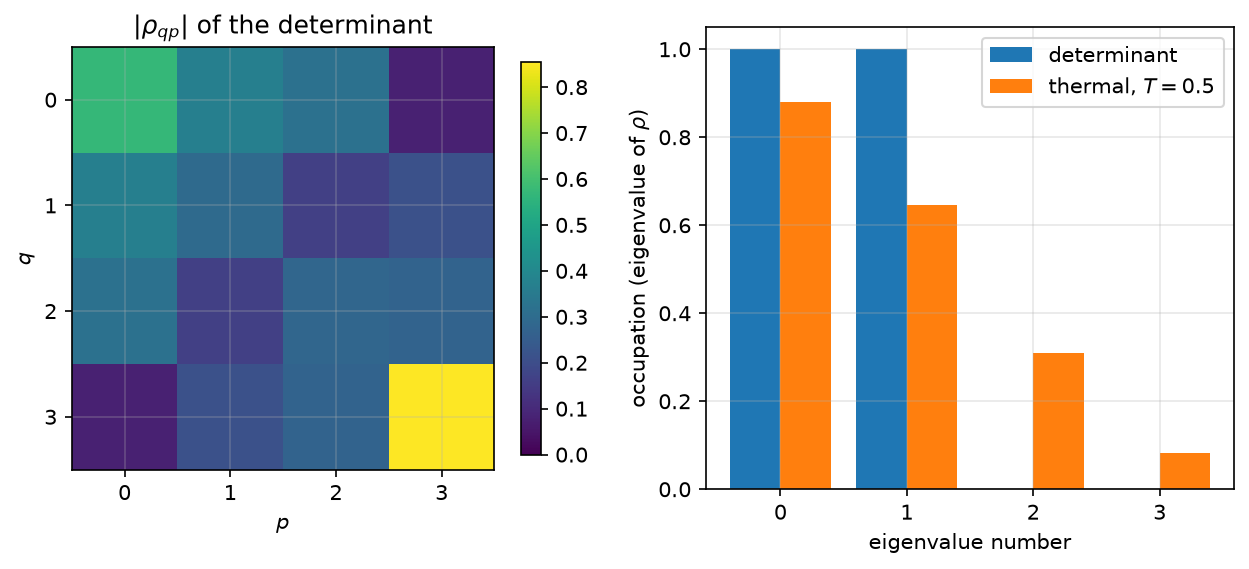

Figure 13c.3 saved as Revision/textbook/figures/13c_3_density_matrices.png
PASS the occupations are 1, 1, 0, 0 and the Fermi-Dirac numbers


In [9]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
image = left.imshow(np.abs(rho_det), cmap="viridis", vmin=0.0)
left.set_title("$|\\rho_{qp}|$ of the determinant")
left.set_xticks(range(M))
left.set_yticks(range(M))
left.set_xlabel("$p$")
left.set_ylabel("$q$")
fig.colorbar(image, ax=left, shrink=0.85)
occupations_det = np.sort(np.linalg.eigvalsh(rho_det))[::-1]
occupations_th = np.sort(np.linalg.eigvalsh(rho_thermal))[::-1]
positions = np.arange(M)
right.bar(positions - 0.2, occupations_det, width=0.4, label="determinant")
right.bar(positions + 0.2, occupations_th, width=0.4, label="thermal, $T = 0.5$")
right.set_xticks(positions)
right.set_xlabel("eigenvalue number")
right.set_ylabel("occupation (eigenvalue of $\\rho$)")
right.legend()
save_figure(fig, "density_matrices",
            "Left: the absolute values of the density matrix "
            "$\\rho_{qp} = \\langle a_p^\\dagger a_q \\rangle$ of a determinant of "
            "two fermions in four randomly mixed orbitals (heat map; $p$ and $q$ "
            "label the four basis orbitals). Right: the eigenvalues of the density "
            "matrices of this determinant (exactly 1, 1, 0, 0) and of a thermal "
            "ensemble of non-interacting fermions at $T = 0.5$ (the Fermi-Dirac "
            "occupations, between 0 and 1); in both cases Wick's theorem holds.")
check(np.allclose(occupations_det, [1, 1, 0, 0], atol=1e-14)
      and np.allclose(occupations_th, np.sort(f)[::-1], atol=1e-14),
      "the occupations are 1, 1, 0, 0 and the Fermi-Dirac numbers")

## 8. The energy of a determinant: direct minus exchange

With a one-body matrix $h_{pq}$ and two-body integrals $w_{pqrs}$ the Hamiltonian is
$\hat H = \sum h_{pq}a_p^\dagger a_q + \tfrac12\sum w_{pqrs}a_p^\dagger a_q^\dagger
a_s a_r$. For the determinant of the basis orbitals 0 and 1 its energy must be
$\sum_{a} h_{aa} + \tfrac12\sum_{a,b}(w_{abab} - w_{abba})$ over $a, b \in \{0,
1\}$. The next cell makes the integrals from four orthonormal orbitals on a grid of
six points and a random symmetric interaction $W(x, x')$ (so that they have the
symmetries of a real interaction) and compares.

In [10]:
chi = np.linalg.qr(rng.normal(size=(6, M)))[0]  # four orthonormal orbitals on 6 points
W_raw = rng.normal(size=(6, 6))
W_pair = (W_raw + W_raw.T) / 2.0  # a symmetric interaction W(x, x')
h_raw = rng.normal(size=(M, M))
h_one = (h_raw + h_raw.T) / 2.0  # a symmetric one-body matrix
# w[p,q,r,s] = sum_{x,x'} chi_p(x) chi_q(x') W(x,x') chi_r(x) chi_s(x')
w = np.einsum("xp,yq,xy,xr,ys->pqrs", chi, chi, W_pair, chi, chi)
H_many = sum(h_one[p, q] * a_dag[p] @ a[q] for p, q in itertools.product(range(M),
                                                                         repeat=2))
H_many = H_many + 0.5 * sum(w[p, q, r, s] * a_dag[p] @ a_dag[q] @ a[s] @ a[r]
                            for p, q, r, s in itertools.product(range(M), repeat=4))
basis_det = a_dag[0] @ a_dag[1] @ vacuum  # occupies the basis orbitals 0 and 1
direct = basis_det @ H_many @ basis_det
formula = sum(h_one[k, k] for k in (0, 1)) + 0.5 * sum(
    w[k, l, k, l] - w[k, l, l, k] for k in (0, 1) for l in (0, 1))
say(f"<Phi|H|Phi> = {direct:.10f};  sum h_aa + (1/2) sum (w_abab - w_abba) = "
    f"{formula:.10f}")
check(abs(direct - formula) < 1e-12,
      "the energy of a determinant is one-body + direct - exchange")

<Phi|H|Phi> = -1.5322375649;  sum h_aa + (1/2) sum (w_abab - w_abba) = -1.5322375649
PASS the energy of a determinant is one-body + direct - exchange


## 9. The two-site model: exact solution

The next cell builds the Hamiltonian of section 4 from the operator matrices (orbital
0 = L up, 1 = R up, 2 = L down, 3 = R down), keeps the four states with one up and
one down electron, and diagonalises it. It checks the closed form of $E_0$ and
computes the double occupancy $\langle \hat n_{L\uparrow}\hat n_{L\downarrow} +
\hat n_{R\uparrow}\hat n_{R\downarrow}\rangle$ of the ground state.

In [11]:
n_op = [a_dag[p] @ a[p] for p in range(M)]  # occupation operators
DOUBLE = n_op[0] @ n_op[2] + n_op[1] @ n_op[3]  # both electrons on one site
# The states with exactly one up (orbital 0 or 1) and one down (2 or 3) electron:
SECTOR = [s for s in range(DIM) if bit(s, 0) + bit(s, 1) == 1
          and bit(s, 2) + bit(s, 3) == 1]


def two_site(t, U, delta=0.0):
    """Ground-state energy, double occupancy and n_L of the two-site model."""
    H = -t * (a_dag[0] @ a[1] + a_dag[1] @ a[0] + a_dag[2] @ a[3] + a_dag[3] @ a[2])
    H = H + U * DOUBLE - 0.5 * delta * (n_op[0] + n_op[2]) \
        + 0.5 * delta * (n_op[1] + n_op[3])
    block = H[np.ix_(SECTOR, SECTOR)]  # the 4 x 4 block of the sector
    values, vectors = np.linalg.eigh(block)
    ground = vectors[:, 0]
    occupancy = ground @ DOUBLE[np.ix_(SECTOR, SECTOR)] @ ground
    n_left = ground @ (n_op[0] + n_op[2])[np.ix_(SECTOR, SECTOR)] @ ground
    return values[0], occupancy, n_left


say(f"the sector holds the states {SECTOR}")
for U in (2.0, 4.0):
    E0, occupancy, n_left = two_site(1.0, U)
    report(f"U = {U:.0f}: exact E_0", f"{E0:.6f}")
    report(f"U = {U:.0f}: exact double occupancy", f"{occupancy:.6f}")
    check(abs(E0 - 0.5 * (U - np.sqrt(U ** 2 + 16.0))) < 1e-12
          and abs(n_left - 1.0) < 1e-12,
          f"U = {U:.0f}: E_0 = (U - sqrt(U^2 + 16 t^2))/2 and n_L = 1")

the sector holds the states [5, 6, 9, 10]
RESULT U = 2: exact E_0 = -1.236068
RESULT U = 2: exact double occupancy = 0.276393
PASS U = 2: E_0 = (U - sqrt(U^2 + 16 t^2))/2 and n_L = 1
RESULT U = 4: exact E_0 = -0.828427
RESULT U = 4: exact double occupancy = 0.146447
PASS U = 4: E_0 = (U - sqrt(U^2 + 16 t^2))/2 and n_L = 1


## 10. Hartree-Fock: restricted and unrestricted

The next cell first checks the energy formula $E(\alpha, \beta)$ of section 4
against the Fock-space expectation value of the determinant
$(\cos\alpha\,a_{L\uparrow}^\dagger + \sin\alpha\,a_{R\uparrow}^\dagger)
(\cos\beta\,a_{L\downarrow}^\dagger + \sin\beta\,a_{R\downarrow}^\dagger)|0\rangle$
at a few angles, then minimises $E(\alpha, \beta)$ on a fine grid of angles for many
values of $U$. With $\beta = \pi/2 - \alpha$ and $s = \sin 2\alpha$ the energy is
$-2ts + \tfrac{U}{2}s^2$ (a parabola in $s \in [0, 1]$), whose minimum gives the
closed forms checked below.

In [12]:
def hf_energy(alpha, beta, U, t=1.0):
    """E(alpha, beta) of the determinant with up (cos a, sin a), down (cos b, sin b)."""
    return (-t * (np.sin(2 * alpha) + np.sin(2 * beta))
            + 0.5 * U * (1.0 + np.cos(2 * alpha) * np.cos(2 * beta)))


H_test = -(a_dag[0] @ a[1] + a_dag[1] @ a[0] + a_dag[2] @ a[3] + a_dag[3] @ a[2]) \
    + 3.0 * DOUBLE  # t = 1, U = 3
worst = 0.0
for alpha, beta in ((0.3, 1.1), (0.7, 0.2), (np.pi / 4, np.pi / 4)):
    det = (np.cos(alpha) * a_dag[0] + np.sin(alpha) * a_dag[1]) @ (
        np.cos(beta) * a_dag[2] + np.sin(beta) * a_dag[3]) @ vacuum
    worst = max(worst, abs(det @ H_test @ det - hf_energy(alpha, beta, 3.0)))
check(worst < 1e-12, "the Hartree-Fock energy formula equals <Phi|H|Phi>")
angles = np.linspace(0.0, np.pi / 2, 1001)
A, B = np.meshgrid(angles, angles, indexing="ij")
U_values = np.linspace(0.0, 8.0, 33)
E_exact = np.array([two_site(1.0, U)[0] for U in U_values])
D_exact = np.array([two_site(1.0, U)[1] for U in U_values])
E_rhf = -2.0 + 0.5 * U_values  # restricted: alpha = beta = pi/4
E_uhf = np.array([hf_energy(A, B, U).min() for U in U_values])  # grid minimum
U_safe = np.where(U_values > 2.0, U_values, 1.0)  # avoids dividing by U = 0
E_closed = np.where(U_values <= 2.0, -2.0 + 0.5 * U_values, -2.0 / U_safe)
check(np.max(np.abs(E_uhf - E_closed)) < 1e-5,
      "the minimum over all determinants is -2t + U/2 (U <= 2t) and -2t^2/U")
check(np.all(E_exact <= E_uhf + 1e-12) and np.all(E_uhf <= E_rhf + 1e-12),
      "variational order: exact <= unrestricted HF <= restricted HF")
E_c = E_exact - E_closed  # correlation energy
report("U = 2: correlation energy E_0 - E_HF", f"{E_c[8]:.6f}")
fine_U = np.linspace(2.0, 8.0, 60001)  # closed forms on a fine grid of U > 2t
fine_c = 0.5 * (fine_U - np.sqrt(fine_U ** 2 + 16.0)) + 2.0 / fine_U
report("U of the largest correlation energy (in size)",
       f"{fine_U[np.argmin(fine_c)]:.3f}")

PASS the Hartree-Fock energy formula equals <Phi|H|Phi>
PASS the minimum over all determinants is -2t + U/2 (U <= 2t) and -2t^2/U
PASS variational order: exact <= unrestricted HF <= restricted HF
RESULT U = 2: correlation energy E_0 - E_HF = -0.236068
RESULT U of the largest correlation energy (in size) = 3.335


The next cell draws the three energies and the correlation energy against $U/t$.

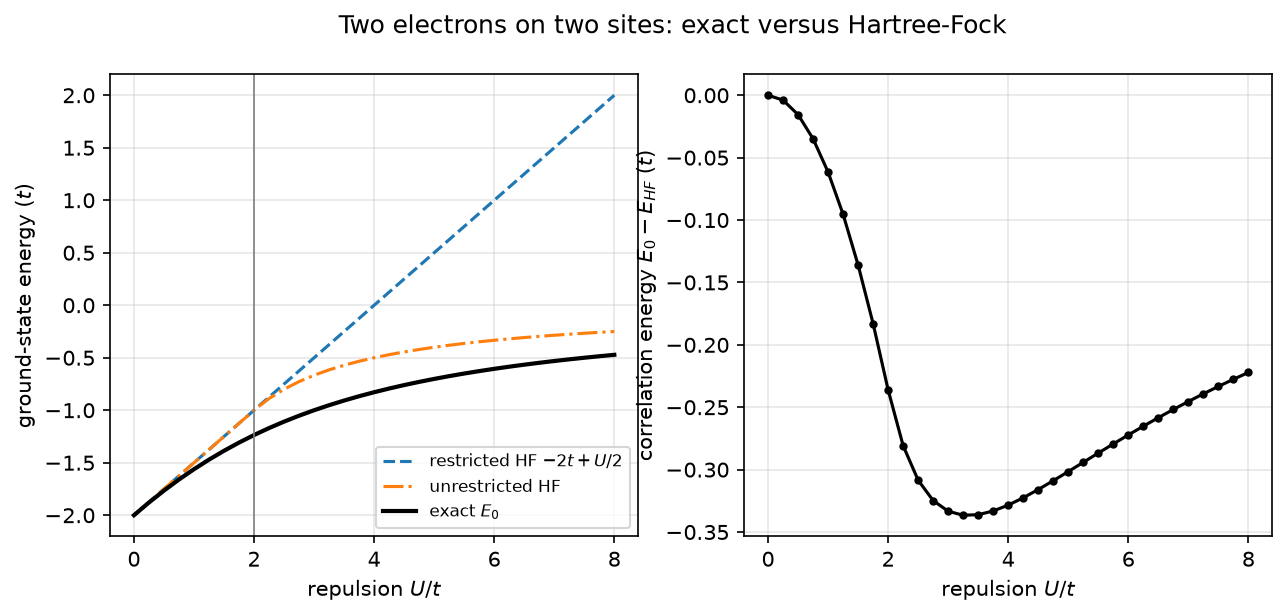

Figure 13c.4 saved as Revision/textbook/figures/13c_4_two_site_energies.png


In [13]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
left.plot(U_values, E_rhf, "--", label="restricted HF $-2t + U/2$")
left.plot(U_values, E_closed, "-.", label="unrestricted HF")
left.plot(U_values, E_exact, color="black", lw=2.0, label="exact $E_0$")
left.axvline(2.0, color="gray", lw=0.8)
left.set_xlabel("repulsion $U/t$")
left.set_ylabel("ground-state energy ($t$)")
left.legend(fontsize=8)
right.plot(U_values, E_c, "o-", ms=3, color="black")
right.set_xlabel("repulsion $U/t$")
right.set_ylabel("correlation energy $E_0 - E_{HF}$ ($t$)")
fig.suptitle("Two electrons on two sites: exact versus Hartree-Fock")
save_figure(fig, "two_site_energies",
            "Left: the ground-state energy of two electrons on two sites against "
            "the repulsion $U/t$: exact (black), restricted Hartree-Fock "
            "$-2t + U/2$ (dashed) and the best determinant, unrestricted for "
            "$U > 2t$ (dash-dotted; the grey line marks $U = 2t$); energies in "
            "units of the hopping $t$. Right: the correlation energy, exact minus "
            "best Hartree-Fock energy, which no single determinant can capture; "
            "its size grows from zero, is largest at about "
            f"$U = {fine_U[np.argmin(fine_c)]:.1f}t$ (beyond the "
            "point $U = 2t$ where restricted and unrestricted Hartree-Fock "
            "separate) and then falls slowly.")

The next cell draws the probability that both electrons sit on the same site. The
restricted determinant always gives $1/2$; the exact state avoids double occupancy
more and more as $U$ grows; the unrestricted determinant gives
$\tfrac12(1 + \cos 2\alpha\cos 2\beta) = 2t^2/U^2$ for $U > 2t$, by breaking the
left-right symmetry of each label.

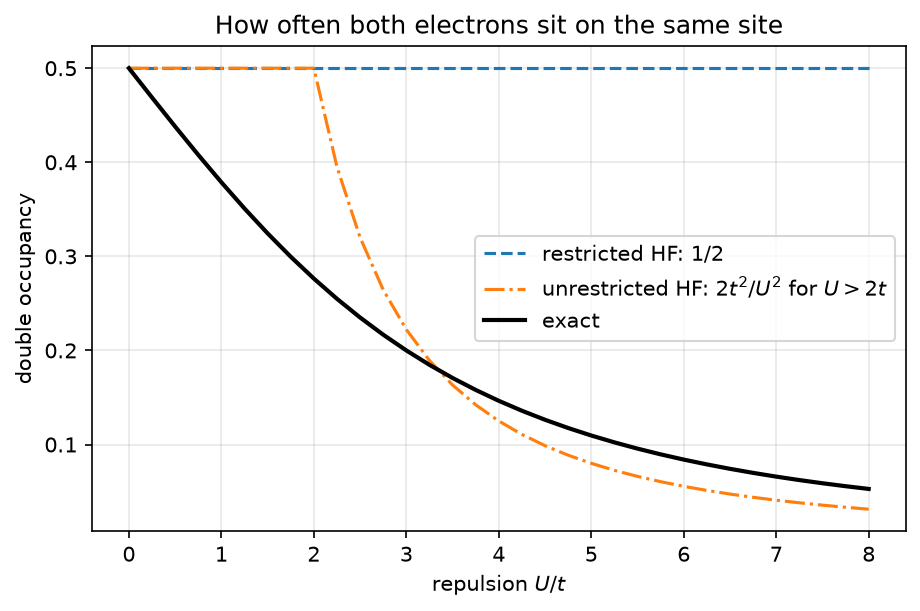

Figure 13c.5 saved as Revision/textbook/figures/13c_5_double_occupancy.png
PASS exact double occupancy 0.276393 at U = 2t and 0.146447 at U = 4t
PASS the exact double occupancy falls as U grows


In [14]:
D_uhf = np.where(U_values <= 2.0, 0.5, 2.0 / U_safe ** 2)
fig, ax = plt.subplots()
ax.plot(U_values, 0.5 * np.ones_like(U_values), "--", label="restricted HF: 1/2")
ax.plot(U_values, D_uhf, "-.", label="unrestricted HF: $2t^2/U^2$ for $U > 2t$")
ax.plot(U_values, D_exact, color="black", lw=2.0, label="exact")
ax.set_xlabel("repulsion $U/t$")
ax.set_ylabel("double occupancy")
ax.set_title("How often both electrons sit on the same site")
ax.legend()
save_figure(fig, "double_occupancy",
            "The probability that both electrons sit on the same site (double "
            "occupancy, a pure number) against $U/t$: exact ground state (black), "
            "restricted Hartree-Fock (always 1/2, dashed) and unrestricted "
            "Hartree-Fock (dash-dotted). The exact electrons avoid each other while "
            "keeping each label shared equally between the sites; a single "
            "determinant can lower the double occupancy only by breaking that "
            "symmetry, and then overshoots.")
check(abs(D_exact[8] - 0.276393) < 1e-6 and abs(D_exact[16] - 0.146447) < 1e-6,
      "exact double occupancy 0.276393 at U = 2t and 0.146447 at U = 4t")
check(np.all(np.diff(D_exact) < 0), "the exact double occupancy falls as U grows")

The next cell draws the Hartree-Fock energy $E(\alpha, \beta)$ at $U = 4t$ as a
contour map. The restricted point $\alpha = \beta = \pi/4$ is a saddle; the two
lowest points (unrestricted solutions) lie on the line $\beta = \pi/2 - \alpha$.

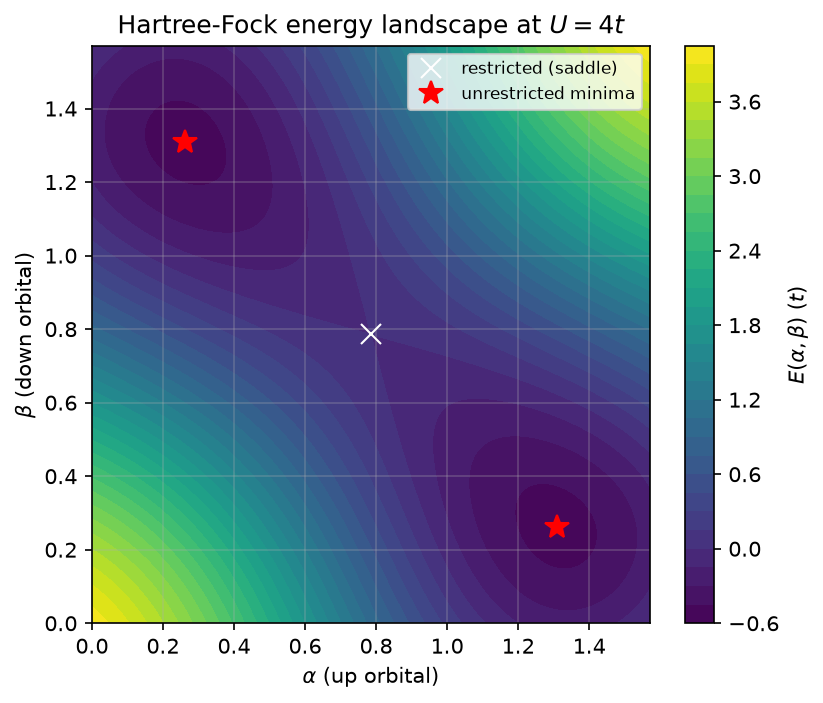

Figure 13c.6 saved as Revision/textbook/figures/13c_6_hf_landscape.png
PASS at U = 4t: minimum -0.5 t, restricted value 0


In [15]:
E_map = hf_energy(A, B, 4.0)
index = np.unravel_index(np.argmin(E_map), E_map.shape)
fig, ax = plt.subplots(figsize=(6.0, 5.0))
contours = ax.contourf(A, B, E_map, levels=30, cmap="viridis")
fig.colorbar(contours, ax=ax, label="$E(\\alpha, \\beta)$ ($t$)")
ax.plot([np.pi / 4], [np.pi / 4], "wx", ms=10, label="restricted (saddle)")
ax.plot([angles[index[0]], angles[index[1]]], [angles[index[1]], angles[index[0]]],
        "r*", ms=12, label="unrestricted minima")
ax.set_xlabel("$\\alpha$ (up orbital)")
ax.set_ylabel("$\\beta$ (down orbital)")
ax.set_title("Hartree-Fock energy landscape at $U = 4t$")
ax.legend(loc="upper right", fontsize=8)
save_figure(fig, "hf_landscape",
            "The energy $E(\\alpha, \\beta)$ of the determinant with the up orbital "
            "$(\\cos\\alpha, \\sin\\alpha)$ and the down orbital "
            "$(\\cos\\beta, \\sin\\beta)$ on the sites (L, R), for $U = 4t$, as a "
            "contour map over the two angles (radians; colors in units of $t$). "
            "The restricted determinant $\\alpha = \\beta = \\pi/4$ (white cross) is "
            "a saddle; the two minima (red stars), mirror images of each other, "
            "put the up electron mostly on one site and the down electron mostly "
            "on the other, with energy $-2t^2/U = -0.5t$.")
check(abs(E_map.min() + 0.5) < 1e-5 and abs(hf_energy(np.pi / 4, np.pi / 4, 4.0)
                                             - 0.0) < 1e-12,
      "at U = 4t: minimum -0.5 t, restricted value 0")

## 11. The Hohenberg-Kohn map and the exact Kohn-Sham potential on two sites

Give the sites the energies $\mp\Delta/2$. For every $\Delta$ the exact ground state
has a density $n_L$ on the left site ($n_R = 2 - n_L$). The Hohenberg-Kohn theorem
says that different $\Delta$ give different $n_L$: the map $\Delta \to n_L$ is
one-to-one, so $n_L$ determines $\Delta$. The next cell computes $n_L(\Delta)$ for
$U = 0, 2, 4$ and checks that it strictly increases.

Kohn and Sham ask: which site-energy difference $\Delta_s$ makes NON-interacting
electrons have the same $n_L$? For two non-interacting electrons in the lowest
orbital of $\begin{pmatrix}-\Delta_s/2 & -t\\ -t & \Delta_s/2\end{pmatrix}$,
$n_L - 1 = \Delta_s/\sqrt{\Delta_s^2 + 4t^2}$, which inverts to
$\Delta_s = 2t\,(n_L - 1)/\sqrt{1 - (n_L - 1)^2}$. The difference $\Delta_s -
\Delta$ is the exact Hartree-exchange-correlation potential difference between the
sites.

In [16]:
deltas = np.linspace(-4.0, 4.0, 81)
density_maps = {U: np.array([two_site(1.0, U, d)[2] for d in deltas])
                for U in (0.0, 2.0, 4.0)}
for U, n_left in density_maps.items():
    check(np.all(np.diff(n_left) > 0),
          f"U = {U:.0f}: n_L increases strictly with Delta (one-to-one map)")


def kohn_sham_delta(n_left, t=1.0):
    """The site-energy difference of non-interacting electrons with density n_L."""
    excess = n_left - 1.0
    return 2.0 * t * excess / np.sqrt(1.0 - excess ** 2)


def free_density(delta_s, t=1.0):
    """n_L of two non-interacting electrons with the site energies -+delta_s/2."""
    values, vectors = np.linalg.eigh(np.array([[-delta_s / 2, -t],
                                               [-t, delta_s / 2]]))
    return 2.0 * vectors[0, 0] ** 2


delta_s = {U: kohn_sham_delta(n) for U, n in density_maps.items()}
rebuilt = max(abs(free_density(ds) - n) for U in density_maps
              for ds, n in zip(delta_s[U], density_maps[U]))
check(rebuilt < 1e-12, "the Kohn-Sham site energies reproduce the exact densities")
check(np.max(np.abs(delta_s[0.0] - deltas)) < 1e-12,
      "without interaction the Kohn-Sham potential is the true one")

PASS U = 0: n_L increases strictly with Delta (one-to-one map)
PASS U = 2: n_L increases strictly with Delta (one-to-one map)
PASS U = 4: n_L increases strictly with Delta (one-to-one map)
PASS the Kohn-Sham site energies reproduce the exact densities
PASS without interaction the Kohn-Sham potential is the true one


The next cell draws the density map $n_L(\Delta)$ for the three repulsions.

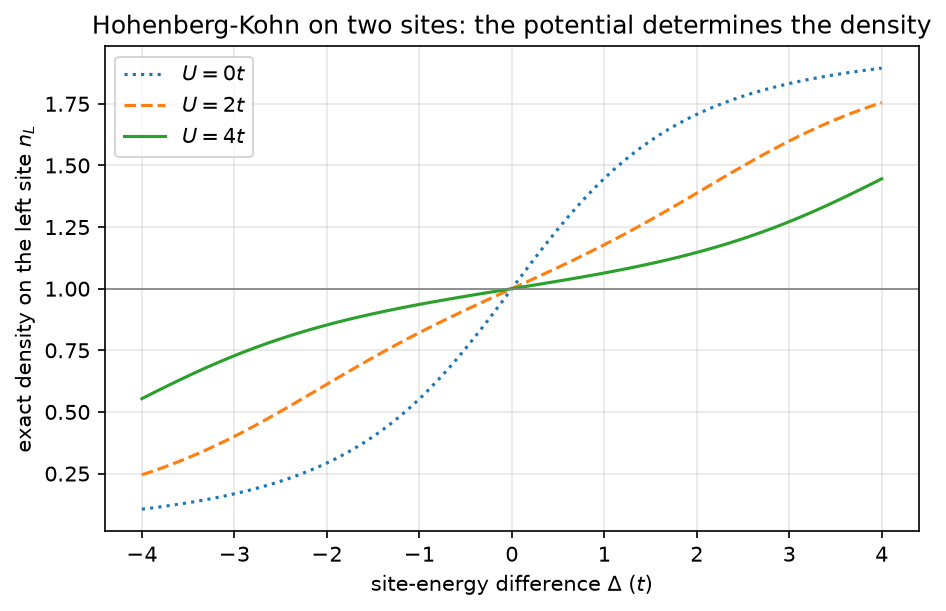

Figure 13c.7 saved as Revision/textbook/figures/13c_7_density_map.png


In [17]:
fig, ax = plt.subplots()
for U, style in ((0.0, ":"), (2.0, "--"), (4.0, "-")):
    ax.plot(deltas, density_maps[U], style, label=f"$U = {U:.0f}t$")
ax.axhline(1.0, color="gray", lw=0.8)
ax.set_xlabel("site-energy difference $\\Delta$ ($t$)")
ax.set_ylabel("exact density on the left site $n_L$")
ax.set_title("Hohenberg-Kohn on two sites: the potential determines the density")
ax.legend()
save_figure(fig, "density_map",
            "The exact ground-state density $n_L$ on the left site of the two-site "
            "model against the site-energy difference $\\Delta$ (units of $t$), "
            "for $U = 0$, $2t$ and $4t$. Every curve rises strictly, so each "
            "density belongs to exactly one $\\Delta$ (the Hohenberg-Kohn theorem "
            "on two sites); the repulsion flattens the curves, because it opposes "
            "piling both electrons on one site.")

For comparison the next cell also computes the potential of the mean-field
(Hartree plus exchange, restricted) approximation, in which each electron feels $U$
times the density of the other label on each site: its site-energy difference is
$\Delta - U(n_L - 1)$, with $n_L$ solved self-consistently (by bisection on the
equation $n_L - 1 = G(n_L - 1)$ with $G(x) = (\Delta - Ux)/\sqrt{(\Delta - Ux)^2 +
4t^2}$; the left side minus the right side increases with $x$, so the root is
unique).

Then it splits the screening $\Delta_s - \Delta$ of the exact Kohn-Sham potential,
AT THE EXACT DENSITY $n_L$, into two parts: the Hartree-exchange part
$\Delta_{Hx} = -U(n_L - 1)$ (the mean-field formula evaluated with the exact
density) and the rest, the correlation part
$\Delta_c = \Delta_s - \Delta - \Delta_{Hx}$. It checks, for $U = 2t$ and $4t$,
that $\Delta_c$ has the sign opposite to $\Delta$ for every $\Delta \ne 0$
(correlation screens further, in the same direction as Hartree and exchange), and
that the self-consistent mean field screens less than the exact Kohn-Sham
potential. Finally it draws the curves.

RESULT U = 4t, Delta = 2t: Hartree-exchange part = -0.588239
RESULT U = 4t, Delta = 2t: correlation part = -1.114408
PASS U = 2t: the correlation part has the sign opposite to Delta
PASS U = 4t: the correlation part has the sign opposite to Delta
PASS U = 4t: the mean field screens less than the exact Kohn-Sham potential


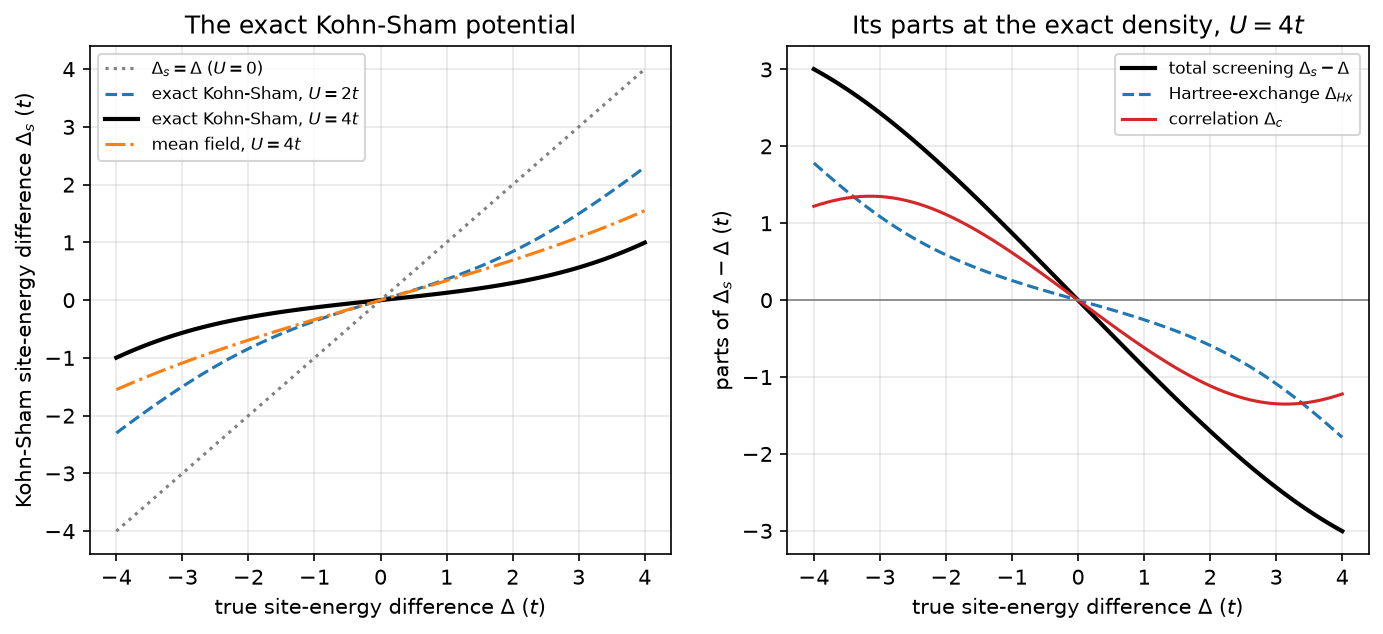

Figure 13c.8 saved as Revision/textbook/figures/13c_8_ks_inversion.png
PASS the repulsion screens the potential: |Delta_s| < |Delta|


In [18]:
def mean_field_excess(delta, U, t=1.0):
    """The self-consistent x = n_L - 1 of restricted Hartree + exchange."""
    low, high = -1.0, 1.0
    for _ in range(80):  # bisection on x - G(x), which increases with x
        middle = 0.5 * (low + high)
        shifted = delta - U * middle
        if middle - shifted / np.sqrt(shifted ** 2 + 4 * t * t) > 0:
            high = middle
        else:
            low = middle
    return 0.5 * (low + high)


mf_delta_s = np.array([d - 4.0 * mean_field_excess(d, 4.0) for d in deltas])
nonzero = np.abs(deltas) > 1e-9  # every Delta except 0
hx_part = {U: -U * (density_maps[U] - 1.0) for U in (2.0, 4.0)}  # at the exact n_L
c_part = {U: delta_s[U] - deltas - hx_part[U] for U in (2.0, 4.0)}  # the rest
report("U = 4t, Delta = 2t: Hartree-exchange part", f"{hx_part[4.0][60]:.6f}")
report("U = 4t, Delta = 2t: correlation part", f"{c_part[4.0][60]:.6f}")
for U in (2.0, 4.0):
    check(np.all(c_part[U][nonzero] * deltas[nonzero] < 0.0),
          f"U = {U:.0f}t: the correlation part has the sign opposite to Delta")
check(np.all(np.abs(mf_delta_s[nonzero]) > np.abs(delta_s[4.0][nonzero])),
      "U = 4t: the mean field screens less than the exact Kohn-Sham potential")
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.4))
left.plot(deltas, deltas, ":", color="gray", label="$\\Delta_s = \\Delta$ ($U = 0$)")
left.plot(deltas, delta_s[2.0], "--", label="exact Kohn-Sham, $U = 2t$")
left.plot(deltas, delta_s[4.0], color="black", lw=2.0,
          label="exact Kohn-Sham, $U = 4t$")
left.plot(deltas, mf_delta_s, "-.", label="mean field, $U = 4t$")
left.set_xlabel("true site-energy difference $\\Delta$ ($t$)")
left.set_ylabel("Kohn-Sham site-energy difference $\\Delta_s$ ($t$)")
left.set_title("The exact Kohn-Sham potential")
left.legend(fontsize=8)
right.plot(deltas, delta_s[4.0] - deltas, color="black", lw=2.0,
           label="total screening $\\Delta_s - \\Delta$")
right.plot(deltas, hx_part[4.0], "--", label="Hartree-exchange $\\Delta_{Hx}$")
right.plot(deltas, c_part[4.0], color="tab:red", label="correlation $\\Delta_c$")
right.axhline(0.0, color="gray", lw=0.8)
right.set_xlabel("true site-energy difference $\\Delta$ ($t$)")
right.set_ylabel("parts of $\\Delta_s - \\Delta$ ($t$)")
right.set_title("Its parts at the exact density, $U = 4t$")
right.legend(fontsize=8)
save_figure(fig, "ks_inversion",
            "Left: the site-energy difference $\\Delta_s$ with which non-interacting "
            "electrons reproduce the exact density of the two-site model, against "
            "the true difference $\\Delta$ (both in units of $t$), for $U = 2t$ "
            "(dashed) and $U = 4t$ (black), with the line $\\Delta_s = \\Delta$ "
            "(dotted) and the self-consistent mean field for $U = 4t$ "
            "(dash-dotted). The interaction screens the potential; the mean field, "
            "which leaves out correlation, screens less. Right: for $U = 4t$, the "
            "screening $\\Delta_s - \\Delta$ (black) split at the exact density "
            "into the Hartree-exchange part $-U(n_L - 1)$ (dashed) and the "
            "correlation part (red); both have the sign opposite to $\\Delta$.")
check(np.all(np.abs(delta_s[4.0][nonzero]) < np.abs(deltas[nonzero])),
      "the repulsion screens the potential: |Delta_s| < |Delta|")

## 12. The last check

The last cell checks that all eight figure files exist and prints the number of
checks that passed.

In [19]:
figure_names = ["slater_determinants", "operator_matrices", "density_matrices",
                "two_site_energies", "double_occupancy", "hf_landscape",
                "density_map", "ks_inversion"]
missing = [name for k, name in enumerate(figure_names, 1)
           if not output_file(f"{FIGURE_FOLDER}/13c_{k}_{name}.png").is_file()]
check(missing == [], "all eight figure files exist")
check(output_file(f"{FIGURE_FOLDER}/13c_8_ks_inversion.png").is_file(),
      "the figure file 13c_8_ks_inversion.png exists")
all_checks_passed()

PASS all eight figure files exist
PASS the figure file 13c_8_ks_inversion.png exists
ALL 33 CHECKS PASSED (notebook 13c)


## 13. What this notebook showed

- A Slater determinant is antisymmetric, vanishes when two fermions meet, is
  normalised, and its density is the sum of its orbital densities.
- Creation and annihilation operators are ordinary matrices on the occupation-number
  states; their anticommutation relations hold exactly.
- Wick's theorem holds for determinants and for thermal ensembles of non-interacting
  fermions; in particular $\langle :S^2:\rangle = (\mathrm{Tr}\,V\rho)^2 -
  \mathrm{Tr}(V\rho V\rho)$, the Hartree-minus-exchange identity that the Revision
  Kohn-Sham theory uses with the vertex $C$.
- The energy of a determinant is the one-body energy plus the direct minus the
  exchange terms.
- For two electrons on two sites: $E_0 = \tfrac12(U - \sqrt{U^2 + 16t^2})$, the best
  determinant gives $-2t + U/2$ ($U \le 2t$) or $-2t^2/U$ ($U > 2t$, unrestricted,
  symmetry broken), and the correlation energy is what no determinant captures. At
  $U = 2t$: $E_0 = -1.236068\,t$, $E_{HF} = -t$, double occupancy 0.276393 versus
  1/2.
- The density determines the site-energy difference (Hohenberg-Kohn on two sites),
  and the exact Kohn-Sham potential exists and screens the true one. At the exact
  density its screening is the Hartree-exchange part $-U(n_L - 1)$ plus a
  correlation part of the same sign; the self-consistent mean field, which leaves
  out correlation, screens less.